# Project 1 — RL Delta Hedging

Trains a PPO agent to hedge a European call option written on GBM stock.
Then benchmarks it against BSM daily-rebalance and BSM weekly-rebalance baselines.

**Run order:** execute cells top-to-bottom.  
Expect ~5 min on CPU for 200k timesteps.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..') / 'src'))

import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.callbacks import EvalCallback

from env import HedgingEnv
from baselines import run_bsm_hedge, record_baseline_metrics
from backtest import evaluate_rl_agent, plot_pnl_comparison, plot_hedge_ratios, plot_cost_comparison
from bsm import bsm_delta

## 0. Quick smoke test — run this before anything else

If this cell errors, the environment is broken and PPO training will crash immediately.
Fix `env.py` before proceeding.

In [2]:
env = HedgingEnv()
obs, _ = env.reset()
for _ in range(21):
    obs, rew, done, _, _ = env.step(env.action_space.sample())
print("Episode completed, final obs:", obs)
assert obs.shape == (3,), f"Unexpected obs shape: {obs.shape}"
print("Smoke test passed.")

Episode completed, final obs: [1.0530419e+00 1.2000000e-08 9.7528756e-01]
Smoke test passed.


## 1. Environment sanity check

In [3]:
ENV_PARAMS = dict(S0=100, K=100, T=21/252, r=0.05,
                  sigma=0.20, n_steps=21, kappa=0.001)

env = HedgingEnv(**ENV_PARAMS)
obs, _ = env.reset(seed=0)
print("Observation space:", env.observation_space)
print("Action space:     ", env.action_space)
print("Initial obs:      ", obs)

# Random rollout
rewards = []
done = False
while not done:
    action = env.action_space.sample()
    obs, r, terminated, truncated, info = env.step(action)
    rewards.append(r)
    done = terminated or truncated

print(f"Episode length: {len(rewards)}, total reward: {sum(rewards):.4f}")

Observation space: Box([0.2 0.  0. ], [5. 1. 1.], (3,), float32)
Action space:      Box(0.0, 1.0, (1,), float32)
Initial obs:       [1.0273924 1.        0.       ]
Episode length: 21, total reward: -6.1512


## 2. BSM baselines

In [4]:
N_EPISODES = 1000

daily_errors, daily_costs = run_bsm_hedge(ENV_PARAMS, n_episodes=N_EPISODES, rebalance_freq=1)
weekly_errors, weekly_costs = run_bsm_hedge(ENV_PARAMS, n_episodes=N_EPISODES, rebalance_freq=5)

print(record_baseline_metrics(daily_errors, daily_costs, 'BSM daily'))
print(record_baseline_metrics(weekly_errors, weekly_costs, 'BSM weekly'))

{'name': 'BSM daily', 'mean_error': 0.05714776363184832, 'std_error': 0.37490866405018286, 'mae': 0.28418752303068334, 'mean_cost': 0.1460989630229981}
{'name': 'BSM weekly', 'mean_error': 0.12147639226344543, 'std_error': 0.6654994594300929, 'mae': 0.49882374122285783, 'mean_cost': 0.09767665352111231}


## 3. Train PPO agent

In [5]:
vec_env = make_vec_env(lambda: HedgingEnv(**ENV_PARAMS), n_envs=4)
eval_env = HedgingEnv(**ENV_PARAMS)

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path='../models/',
    log_path='../results/',
    eval_freq=5000,
    n_eval_episodes=100,
    deterministic=True,
    verbose=0,
)

model = PPO(
    'MlpPolicy', vec_env,
    learning_rate=3e-4,
    n_steps=256,
    batch_size=64,
    n_epochs=10,
    gamma=0.99,
    policy_kwargs=dict(net_arch=[64, 64]),
    verbose=1,
)

model.learn(total_timesteps=200_000, callback=eval_callback)
model.save('../models/ppo_hedge_v1')
print('Saved ppo_hedge_v1')

Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 21       |
|    ep_rew_mean     | -13.8    |
| time/              |          |
|    fps             | 9448     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 1024     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 21           |
|    ep_rew_mean          | -14.7        |
| time/                   |              |
|    fps                  | 4451         |
|    iterations           | 2            |
|    time_elapsed         | 0            |
|    total_timesteps      | 2048         |
| train/                  |              |
|    approx_kl            | 0.0031572687 |
|    clip_fraction        | 0.00635      |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.41        |
|    explained_variance   | -0.00739     

/opt/anaconda3/envs/scaf/lib/python3.11/site-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


------------------------------------------
| eval/                   |              |
|    mean_ep_length       | 21           |
|    mean_reward          | -4.34        |
| time/                   |              |
|    total_timesteps      | 20000        |
| train/                  |              |
|    approx_kl            | 0.0068689086 |
|    clip_fraction        | 0.0673       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.42        |
|    explained_variance   | 0.438        |
|    learning_rate        | 0.0003       |
|    loss                 | 6.91         |
|    n_updates            | 190          |
|    policy_gradient_loss | -0.00785     |
|    std                  | 0.994        |
|    value_loss           | 11.4         |
------------------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 21       |
|    ep_rew_mean     | -11.6    |
| time/              |          |
|    fps     

## 4. Hyperparameter sweep (optional — runs 4 variants)

In [6]:
sweep_configs = [
    dict(kappa=0.000, net_arch=[64,64],   lr=3e-4, name='no_tc'),
    dict(kappa=0.001, net_arch=[64,64],   lr=3e-4, name='base'),
    dict(kappa=0.001, net_arch=[128,64],  lr=3e-4, name='wider'),
    dict(kappa=0.001, net_arch=[64,64],   lr=1e-4, name='slow_lr'),
]

sweep_results = {}
for cfg in sweep_configs:
    params = {**ENV_PARAMS, 'kappa': cfg['kappa']}
    venv = make_vec_env(lambda: HedgingEnv(**params), n_envs=4)
    m = PPO('MlpPolicy', venv,
            learning_rate=cfg['lr'],
            n_steps=256, batch_size=64, n_epochs=10,
            policy_kwargs=dict(net_arch=cfg['net_arch']),
            verbose=0)
    m.learn(total_timesteps=100_000)
    m.save(f"../models/ppo_{cfg['name']}")
    sweep_results[cfg['name']] = m
    print(f"Done: {cfg['name']}")

Done: no_tc
Done: base
Done: wider
Done: slow_lr


## 5. Evaluate RL agent vs baselines

In [7]:
model = PPO.load('../models/ppo_hedge_v1')

rl_results = evaluate_rl_agent(model, HedgingEnv, ENV_PARAMS, n_episodes=N_EPISODES)
rl_pnl = rl_results['terminal_pnl']
rl_costs = rl_results['episode_tc']

print('RL agent terminal PnL: mean={:.4f}, std={:.4f}, MAE={:.4f}'.format(
    np.mean(rl_pnl), np.std(rl_pnl), np.mean(np.abs(rl_pnl))))

print('RL agent costs:   mean={:.4f}'.format(np.mean(rl_costs)))
print('BSM daily costs:  mean={:.4f}'.format(np.mean(daily_costs)))
print('BSM weekly costs: mean={:.4f}'.format(np.mean(weekly_costs)))

RL agent terminal PnL: mean=-3.5624, std=5.0997, MAE=3.5667
RL agent costs:   mean=0.1306
BSM daily costs:  mean=0.1461
BSM weekly costs: mean=0.0977


## 6. Plots

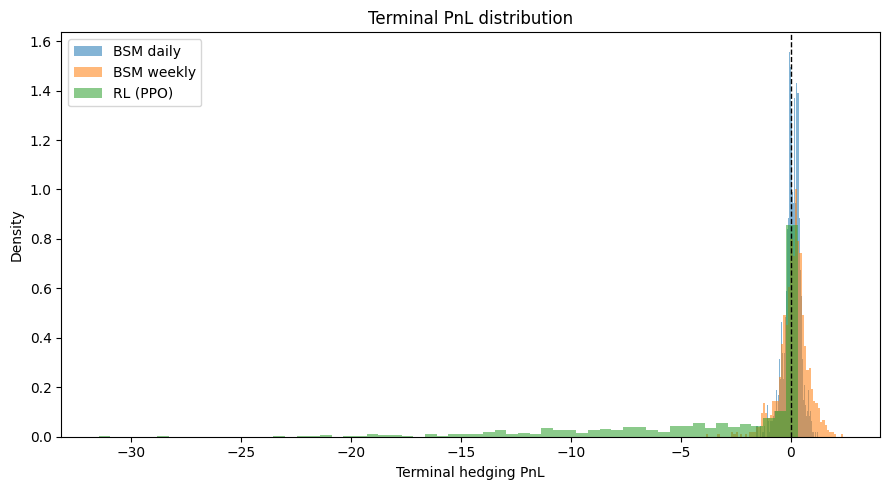

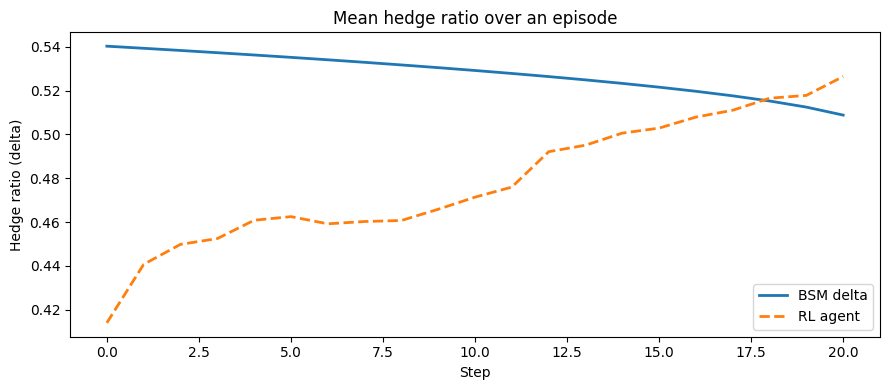

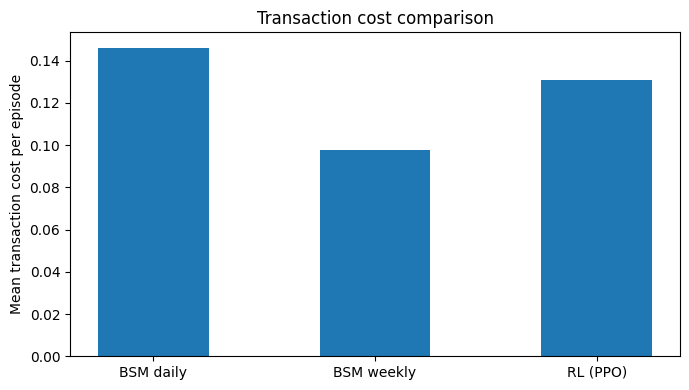

In [8]:
# Terminal PnL distributions
plot_pnl_comparison({
    'BSM daily':  daily_errors,
    'BSM weekly': weekly_errors,
    'RL (PPO)':   rl_pnl,
})

# Average hedge ratio over an episode
# BSM benchmark: compute bsm_delta at each step for ATM option
n_steps = ENV_PARAMS['n_steps']
dt = ENV_PARAMS['T'] / n_steps
bsm_path = np.array([
    bsm_delta(100, 100, max(ENV_PARAMS['T'] - t*dt, 1e-9),
              ENV_PARAMS['r'], ENV_PARAMS['sigma'])
    for t in range(n_steps)
])

# RL average path
max_ep_len = max(len(p) for p in rl_results['delta_paths'])
padded = np.array([p + [p[-1]] * (max_ep_len - len(p))
                   for p in rl_results['delta_paths']])
rl_path = padded.mean(axis=0)

plot_hedge_ratios(bsm_path, rl_path)

# Transaction costs
plot_cost_comparison({
    'BSM daily':  float(np.mean(daily_costs)),
    'BSM weekly': float(np.mean(weekly_costs)),
    'RL (PPO)':   float(np.mean(rl_costs)),
})